<a href="https://colab.research.google.com/github/gajendran61/internship-project/blob/master/hyreAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
df = pd.read_csv('/content/placement_dataset_30_students.csv')

df.head()

,StudentID,StudentName,Gender,Department,CGPA,TenthPercentage,TwelfthPercentage,AptitudeScore,CommunicationScore,TechnicalScore,ProjectsCompleted,Internships,Certifications,CodingScore,MockInterviewScore,Attendance,Backlogs,PlacementStatus
0,STU001,Aarav Sharma,Male,CSE,8.9,92,89,85,82,88,4,2,3,90,85,95,0,Placed
1,STU002,Priya Nair,Female,IT,8.5,88,91,80,90,84,3,1,2,85,88,93,0,Placed
2,STU003,Rahul Kumar,Male,ECE,7.1,78,75,60,65,62,1,0,1,58,60,82,2,Not Placed
3,STU004,Ananya Reddy,Female,CSE,9.2,95,94,92,89,94,5,2,4,95,92,98,0,Placed
4,STU005,Vikram Singh,Male,EEE,7.8,84,81,74,70,76,2,1,1,72,74,88,1,Placed


In [ ]:
print(df.shape)

print(df.info())

print(df.describe())

(30, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           30 non-null     object 
 1   StudentName         30 non-null     object 
 2   Gender              30 non-null     object 
 3   Department          30 non-null     object 
 4   CGPA                30 non-null     float64
 5   TenthPercentage     30 non-null     int64  
 6   TwelfthPercentage   30 non-null     int64  
 7   AptitudeScore       30 non-null     int64  
 8   CommunicationScore  30 non-null     int64  
 9   TechnicalScore      30 non-null     int64  
 10  ProjectsCompleted   30 non-null     int64  
 11  Internships         30 non-null     int64  
 12  Certifications      30 non-null     int64  
 13  CodingScore         30 non-null     int64  
 14  MockInterviewScore  30 non-null     int64  
 15  Attendance          30 non-null     int64  
 16  B

In [ ]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df['Department'] = le.fit_transform(df['Department'])

df['PlacementStatus'] = le.fit_transform(df['PlacementStatus'])

In [ ]:
X = df.drop(
    ['StudentID',
     'StudentName',
     'PlacementStatus'],
    axis=1
)

y = df['PlacementStatus']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

In [ ]:
pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Accuracy =", round(accuracy*100,2), "%")

Accuracy = 100.0 %


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


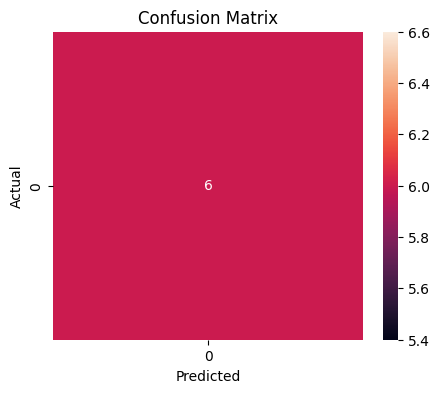

In [ ]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

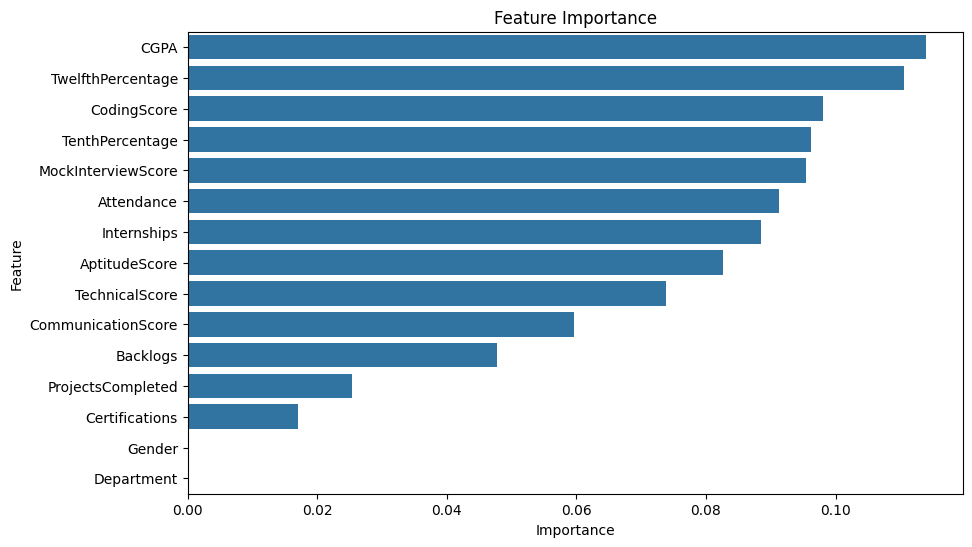

In [ ]:
importance = model.feature_importances_

feat = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feat = feat.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feat,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

In [ ]:
student = pd.DataFrame({

'Gender':[1],
'Department':[0],
'CGPA':[8.9],
'TenthPercentage':[92],
'TwelfthPercentage':[90],
'AptitudeScore':[88],
'CommunicationScore':[85],
'TechnicalScore':[90],
'ProjectsCompleted':[4],
'Internships':[2],
'Certifications':[3],
'CodingScore':[91],
'MockInterviewScore':[88],
'Attendance':[95],
'Backlogs':[0]

})

prediction = model.predict(student)

probability = model.predict_proba(student)

print("Placement Prediction:",
      "Placed" if prediction[0]==1 else "Not Placed")

print("Placement Probability:",
      round(max(probability[0])*100,2),
      "%")

Placement Prediction: Placed
Placement Probability: 100.0 %
